<font color='red' size='6'>REMINDER</font>

# Fill in any place that says `YOUR CODE HERE`.
- You should remove the line that says `raise NotImplementedError()`. If you do not, your code will (unsurprisingly) throw a run-time error and cause everything to fail.
- Do **NOT** write your answer anywhere else other than where it says `YOUR CODE HERE`. Simply write your code directly below this comment in the **same code cell**.

# Make sure everything runs as expected.
- Go to the menubar, select *Kernel* > *Restart & Run All*

# Do <ins>NOT</ins> change the title (i.e., file name) of this notebook.

# Do <ins>NOT</ins> delete any of the cells in this notebook.

# Make sure you save your work
- Go to the menubar, select *File* > *Save and Checkpoint*

In [ ]:
# Run this code cell before attempting to validate
from nose.tools import assert_equal, assert_in, assert_is_instance
from nose.tools import assert_almost_equal, assert_not_equal

-----

# Problem 1: Time Series Analysis

Be sure to complete these steps in the order outlined below and in their appropriate code cells. There is file named `META.csv` in the subfolder `data`. It contains the trading data for the company Meta.

1. Use `pandas` to read the file into a `DataFrame` named `meta`, being sure to use a `RangeIndex` and making sure any date columns come in as a true date object.
2. Convert the column names to have all lower case characters. Replace any spaces between words with the underscore character. These changes should be reflected in the existing `meta` `DataFrame`.
3. Change the index for `meta` to be the `date` column.
4. Create a line plot of the for the closing price.

In [ ]:
# import pandas using the alias pd
import pandas as pd

# Use `pandas` to read the file into a `DataFrame` named `meta`,
# being sure to use a `RangeIndex` and making sure any date
# columns come in as a true date object.
meta = pd.read_csv('./data/META.csv')
meta['Date'] = pd.to_datetime(meta['Date'])
meta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       251 non-null    datetime64[ns]
 1   Open       251 non-null    float64       
 2   High       251 non-null    float64       
 3   Low        251 non-null    float64       
 4   Close      251 non-null    float64       
 5   Adj Close  251 non-null    float64       
 6   Volume     251 non-null    int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 13.9 KB


In [ ]:
# This is a test cell
# If **NO** message is printed, it means that the tests passed
# One basic test to see if your code works
assert_equal(type(meta.index), pd.core.indexes.range.RangeIndex, msg='You did not use a RangeIndex when reading in the data as instructed.')
import numpy as np
assert_equal(meta.Date.dtype, np.dtype('<M8[ns]'), msg='You did not set the `Date` column as a datetime[ns] data type')

In [ ]:
# Convert the column names to have all lower case characters.
# Replace any spaces between words with the underscore character.
# These changes should be reflected in the existing `meta` `DataFrame`.
# YOUR CODE HERE
meta.columns = [col.lower().replace(" ", "_") for col in meta.columns]
meta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       251 non-null    datetime64[ns]
 1   open       251 non-null    float64       
 2   high       251 non-null    float64       
 3   low        251 non-null    float64       
 4   close      251 non-null    float64       
 5   adj_close  251 non-null    float64       
 6   volume     251 non-null    int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 13.9 KB


In [ ]:
# Change the index for `meta` to be the `date` column.
# YOUR CODE HERE
meta = meta.set_index('date')
meta.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 251 entries, 2022-01-03 to 2022-12-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   open       251 non-null    float64
 1   high       251 non-null    float64
 2   low        251 non-null    float64
 3   close      251 non-null    float64
 4   adj_close  251 non-null    float64
 5   volume     251 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 13.7 KB


<hr>

<AxesSubplot:xlabel='date'>

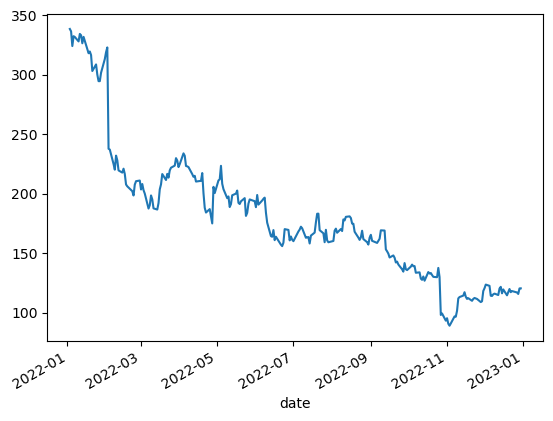

In [ ]:
# Create a line plot of the for the closing price.
meta.close.plot(kind='line')

-----

# Problem 2: Distribution Analysis

Be sure to complete these steps in the order outlined below and in their appropriate code cells. There is file named `customers.csv` in the subfolder `data`. It contains information on the customers of one of your clients.
1. Read the file into a `DataFrame` named `cust`.
2. Use `seaborn` to create a histogram (using all the defaults) for the amount spent.
3. Use `seaborn` to create a histogram for household income, split by marital status. Set the transparency to 0.25 and add a kernel density estimation line.
4. Use `seaborn` to create a boxplot for spending broken out by gender.

In [ ]:
# Read the file into a `DataFrame` named `cust`.
cust = pd.read_csv('./data/customers.csv')
cust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8157 entries, 0 to 8156
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   cust_id             8157 non-null   object
 1   join_date           8157 non-null   object
 2   gender              8157 non-null   object
 3   age                 8157 non-null   int64 
 4   marital_status      8157 non-null   object
 5   household_income    8157 non-null   int64 
 6   home_ownership      8157 non-null   object
 7   num_children        8157 non-null   int64 
 8   num_vehicles        8157 non-null   int64 
 9   last_purchase_date  8157 non-null   object
 10  spend               8157 non-null   int64 
dtypes: int64(5), object(6)
memory usage: 701.1+ KB


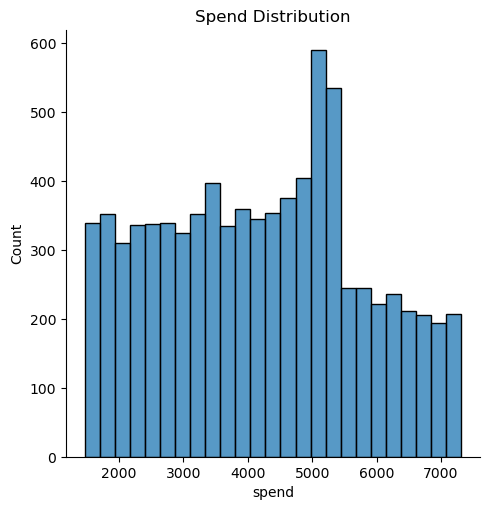

In [ ]:
# Use `seaborn` to create a histogram for the amount spent.
import matplotlib.pyplot as plt
import seaborn as sns

sns.displot(data=cust, x='spend', kind='hist').set(title='Spend Distribution')

### Carefully explain the important attributes of the histogram you created for spending in the Markdown cell below.

Amount spent remains relatively flat until approaching a concentration around the $5,000 threshold, followed by a sharp decrease and plateau.

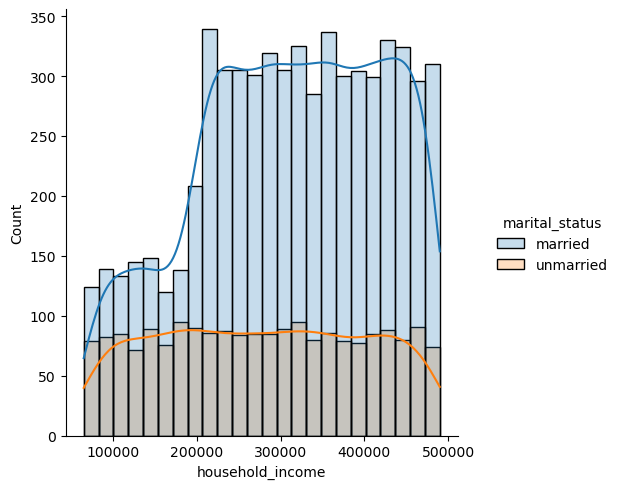

In [ ]:
# Use `seaborn` to create a histogram for household income,
# split by marital status. Set the transparency to 0.25
# and add a kernel density estimation line.
sns.displot(data=cust, x='household_income', hue='marital_status', kde=True, alpha=.25)

### Carefully explain the the histogram you created for household income in the Markdown cell below.

Household income for unmarried persons seems relatively flat and uniform across all income levels. For household income for married persons, we observe a steep increase around the $200,000 threshold, followed by a plateau. Average income for married persons is likely higher than unmarried persons. This pattern may be due to dual income households.

<AxesSubplot:xlabel='gender', ylabel='spend'>

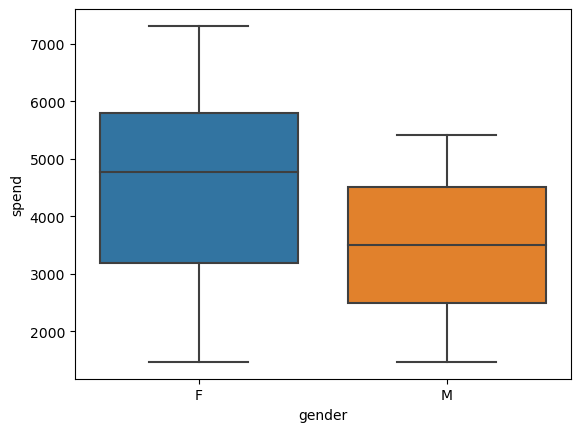

In [ ]:
# Use `seaborn` to create a boxplot for spending broken out by gender.
plt.figure()
sns.boxplot(data=cust, x='gender', y='spend')

### Carefully explain the the boxplot you created in the Markdown cell below.

Minimum spending seems to be simillar among men and women within this dataset; however, women spend more than men on average and have a greater range of spending. No outliers seem to be present.

-----

# Problem 3: Relationship Analysis

Be sure to complete these steps in the order outlined below and in their appropriate code cells. There is file named `customers.csv` in the subfolder `data`. It contains information on customers of one of your clients.
1. Use `seaborn` to create a heatmap of the correlation matrix for all of the quantitative variables in the customer dataset. Be sure add labels to the squares and have the color range from -1 to +1.
2. Which variable has the strongest correlation to spending? Save the name of the column in a variable named `strongest_corr_to_spend`. Be sure to use the name **exactly** as found in the column names.
3. Create a sample of 100 rows from the `cust` `DataFrame` using a seed of 71. Store the results in a variable named `sample`. Using `sample`, create a scatter plot with `matplotlib` between the spending and the variable with the strongest correlation. Be sure to place the variables on the correct axes.

<AxesSubplot:>

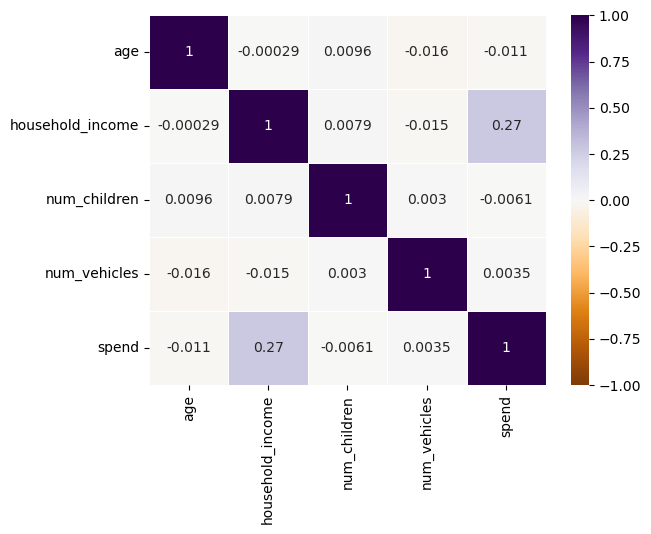

In [ ]:
# Use `seaborn` to create a heatmap of the correlation matrix for
# all of the quantitative variables in the customer dataset.
# Be sure add labels to the squares and have the color range
# from -1 to +1.
sns.heatmap(cust.corr(), annot=True, linewidths=0.5, cmap='PuOr', vmin=-1.0, vmax=1.0)

In [ ]:
# Which variable has the strongest correlation to spending?
# Save the name of the column in a variable named `strongest_corr_to_spend`.
# Be sure to use the name as **exactly** found in the column names.
#Observing the created plot above, we deduce that the column with the strongest correlation is 'household_income'.
strongest_corr_to_spend = 'household_income'

<hr>

<AxesSubplot:xlabel='household_income', ylabel='spend'>

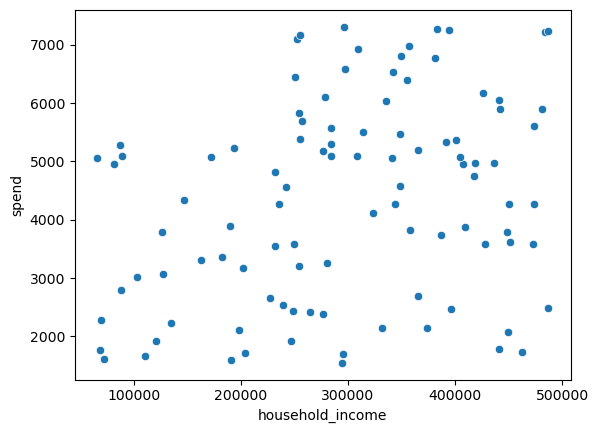

In [ ]:
#  Create a sample of 100 rows from the `cust` `DataFrame` using a seed of 71.
# Store the results in a variable named `sample`. Using `sample` create a
# scatter plot between the spending and the variable with the strongest correlation.
# Be sure to place the variables on the correct axes.
sample = cust.sample(n=100, random_state=71)

sns.scatterplot(data=sample, x=strongest_corr_to_spend, y='spend')

-----

# Problem 4

Be sure to complete these steps in the order outlined below and in their appropriate code cells. There is file named `customers.csv` in the subfolder `data`. It contains information on the customers of one of your clients.
1. Add a new column named `spend_category` the `cust` `DataFrame`. The column should contain the categories "low", "medium", and "high" for amount spent. Those three bins should be equal-width. (Sanity check: This means there will probably be a different number of observations in each bin.)
2. Find the average for all of the numerical columns of `cust` across your newly created column `spend_category`. Store the results in a `DataFrame` variable named `averages`.
3. Find the minimum, maximum, average, and count for the column `spend` across each `spend_category`. Store the results in a variable named `summary`.
4. Create a frequency table that has spending category on the rows and marital status in the columns. Be sure to add totals for both the rows and columns. Store your results in a variable named `freq_table`.
5. Create a frequency table that has spending category on the rows and marital status in the columns. This time make the values be the percentage/fraction. Be sure that each **row** adds to 100% (i.e., 1), including the total row. You should **not** have a column that is labeled "All". Store your results in a variable named `percent_table`.

In [ ]:
# Add a new column named `spend_category` the `cust` `DataFrame`.
# The column should contain the categories "low", "medium", and
# "high" for amount spent.
cust = cust.assign(spend_category = pd.cut(cust.spend, bins=3, labels=['low', 'medium', 'high']))

<hr>

In [ ]:
# Find the average for all of the numerical columns of `cust`
# across your newly created column `spend_category`.
# Store the results in a variable named `averages`.
averages = cust.groupby('spend_category').mean()
averages

,age,household_income,num_children,num_vehicles,spend
spend_category,,,,,
low,38.008843,275349.043863,2.461620,2.483905,2451.078882
medium,38.082140,287373.866998,2.494592,2.526162,4484.845659
high,37.661603,364623.092719,2.417496,2.503929,6265.764798


In [ ]:
# This is a test cell
# If **NO** message is printed, it means that the tests passed
# One basic test to see if your code works
assert_equal(averages.index.name, 'spend_category', msg='You did not create the `averages` DataFrame correctly')

<hr>

In [ ]:
# Find the minimum, maximum, average, and count for the column `spend`
#across each `spend_category`. Store the results in a variable named `summary`.
summary = cust.groupby('spend_category')['spend'].agg(['min', 'max', 'mean', 'count'])
summary

,min,max,mean,count
spend_category,,,,
low,1467,3415,2451.078882,2827
medium,3417,5363,4484.845659,3421
high,5364,7312,6265.764798,1909


In [ ]:
# This is a test cell
# If **NO** message is printed, it means that the tests passed
# One basic test to see if your code works
high_count = summary.loc['high']['count']
assert_equal(high_count, 1909, msg='You did not find the correct count for high spenders')

<hr>

In [ ]:
# Create a frequency table that has spending category on the rows and
# marital status in the columns. Be sure to add totals for both the
# rows and columns. Store your results in a variable named `freq_table`.
freq_table = pd.crosstab(index=cust.spend_category, columns=cust.marital_status, colnames=['marital_status'], margins=True)
freq_table

marital_status,married,unmarried,All
spend_category,,,
low,1876,951,2827
medium,2374,1047,3421
high,1889,20,1909
All,6139,2018,8157


<hr>

In [ ]:
# Create a frequency table that has spending category on the rows and
# marital status in the columns. This time make the values be the
# percentage/fraction. Be sure that each **row** adds to 100% (i.e., 1),
# including the total row. You should **not** have a column that is
# labeled "All" Store your results in a variable named `percent_table`.
percent_table = pd.crosstab(index=cust.spend_category, columns=cust.marital_status, colnames=['marital_status'], normalize='index', margins=True)
percent_table

marital_status,married,unmarried
spend_category,,
low,0.663601,0.336399
medium,0.693949,0.306051
high,0.989523,0.010477
All,0.752605,0.247395


<hr>

**&copy; 2022 - Present: Matthew D. Dean, Ph.D.   
Clinical Associate Professor of Business Analytics at William \& Mary.**